In [5]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [6]:
pip install graphviz



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
class Value:
  def __init__(self,data,_children=(),_op='',label=''):
    self.data=data
    self.grad=0.0
    self._backward=lambda:None
    self._prev=tuple(_children)
    self._op=_op
    self.label=label
#这些都是magic method,__repr__是可以输入a b查看数据多少以及名称，__add__啥的都是重载，是写到python协议里的
  """
  这两点其实涉及到了 Python 对象模型中非常核心的概念：
  魔术方法（Magic Methods）。
  我们可以把它们看作是 Python 预留的“后门”，让你的自定义类能像内置类型（比如整数、列表）一样自然。
  """
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out=Value(self.data+other.data,(self,other),'+')

    """这是一个闭包（Closure）。它定义了一个函数，但现在不执行。
    它被存在 out._backward 里，像是一个“锦囊妙计”，
    等到以后我们调用 loss.backward() 时，才会按照从后往前的顺序打开这个锦囊。"""
  #实际上就是闭包
  #加法的梯度就是自己，所以乘1.0
    def _backward():
      self.grad += 1.0*out.grad
      other.grad += 1.0*out.grad
    out._backward=_backward
    return out
  

  def __mul__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out=Value(self.data*other.data,(self,other),'*')
  #乘法的梯度有链式法则，需要算输出的梯度等于输入的梯度*当前的梯度
    def _backward():
      self.grad += other.data*out.grad
      other.grad += self.data*out.grad
    out._backward=_backward
    return out
  
  def __pow__(self,other):
    assert isinstance(other,(int,float)),"only supporting int/float powers for now"
    out=Value(self.data**other,(self,),f'**{other}')
    def _backward():
      self.grad += (other*(self.data**(other-1)))*out.grad
    out._backward=_backward
    return out
  
  def __radd__(self,other): #other+self
    return self + other

  def __rmul__(self,other): #other*self
    return self * other

  def __truediv__(self,other): #self/other
    return self*other**-1
  
  def __neg__(self):
    return self * -1
  
  def __sub__(self,other):
    return self + (-other)
  
  def __rsub__(self,other): #other-self
    return other + (-self)

  def tanh(self):
    x=self.data
    """
    (e^2*x-1)/(e^2*x+1)
    """
    t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
    out=Value(t,(self,),'tanh')
    #输入端的梯度 = 本地梯度 * 输出端的梯度（上游传回来的梯度）。
    def _backward():
      self.grad += (1-t**2)*out.grad
    out._backward=_backward

    return out
  
  def exp(self):
    x=self.data
    out=Value(math.exp(x),(self, ),'exp')

    def _backward():
      self.grad += out.data*out.grad
    out._backward=_backward
  
    return out
  def backward(self):
        #生成的拓扑图
    topo=[]
    visited=set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)
    
    self.grad=1.0
    for node in reversed(topo):
      node._backward()

In [8]:
x1=Value(2.0)

x2=Value(0.0)
x1 - x2

Value(data=2.0)

In [9]:
def trace(root):
  nodes, edges = [], []
  seen = set()

  def build(v):
    if v not in seen:
      seen.add(v)
      nodes.append(v)
      for child in v._prev:
        edges.append((child, v))
        build(child)

  build(root)
  return nodes, edges


def draw_dot(root):
  try:
    from graphviz import Digraph
  except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
      "需要先安装 graphviz：pip install graphviz。"
      "如果还渲染不出来，还需要安装系统 Graphviz 程序。"
    ) from exc

  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)

  for n in nodes:
    uid = str(id(n))
    dot.node(
      name=uid,
      label='{ %s | data %.4f | grad %.4f }' % (n.label, n.data, n.grad),
      shape='record'
    )
    if n._op:
      dot.node(name=uid + n._op, label=n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [10]:
#inputs x1,x2
x1=Value(2.0,label='x1')
x2=Value(3.0,label='x2')
#weights w1,w2
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias of the neuron
b=Value(6.88888,label='b')
#n=0
# x1*w1+x2*w2+b
x1w1=x1*w1;x1w1.label='x1*w1'
x2w2=x2*w2;x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1*w1 + x2*w2'
n=x1w1x2w2+b;n.label='n';
o=n.tanh();o.label='o'
o.backward()

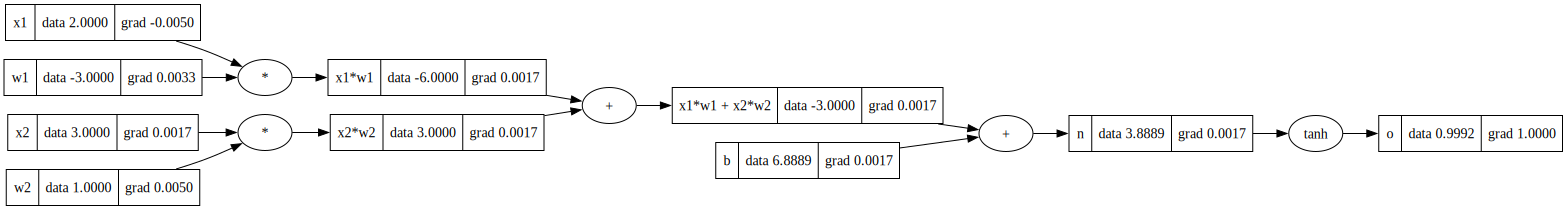

In [11]:
draw_dot(o)

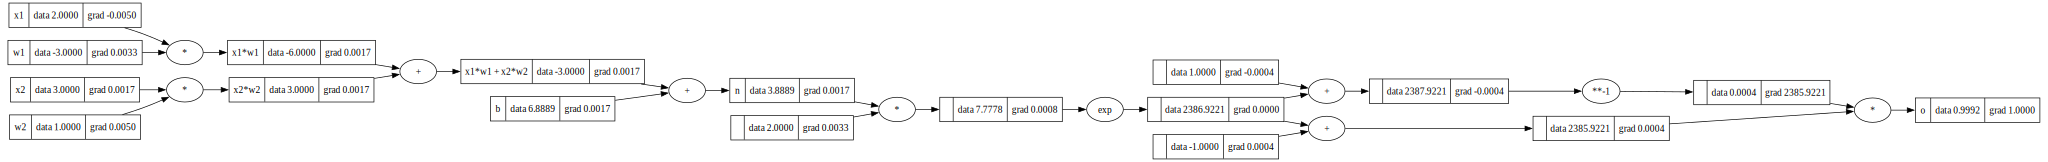

In [12]:
#inputs x1,x2
x1=Value(2.0,label='x1')
x2=Value(3.0,label='x2')
#weights w1,w2
w1=Value(-3.0,label='w1')
w2=Value(1.0,label='w2')
#bias of the neuron
b=Value(6.88888,label='b')
#n=0
# x1*w1+x2*w2+b
x1w1=x1*w1;x1w1.label='x1*w1'
x2w2=x2*w2;x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2;x1w1x2w2.label='x1*w1 + x2*w2'
n=x1w1x2w2+b;n.label='n';
#---
e=(2*n).exp()
o=(e-1)/(e+1)
#---
o.label='o'
o.backward()
draw_dot(o)

In [13]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [14]:
import torch
import random

In [15]:

x1=torch.Tensor([2.0]).double(); x1.requires_grad=True
x2=torch.Tensor([0.0]).double(); x2.requires_grad=True
w1=torch.Tensor([-3.0]).double(); w1.requires_grad=True
w2=torch.Tensor([1.0]).double(); w2.requires_grad=True
b=torch.Tensor([6.88888]).double(); b.requires_grad=True
n=x1*w1+x2*w2+b
o=torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())

0.7108399908924977
-----
x2 0.49470650734795374
w2 0.0
x1 -1.4841195220438612
w1 0.9894130146959075


In [16]:
x2.grad.item()

0.49470650734795374

`zip` 的意思就是：**把几个列表按位置“拉链式”配对起来**。

比如：

```python
a = [1, 2, 3]
b = ['a', 'b', 'c']

list(zip(a, b))
```

结果是：

```python
[(1, 'a'), (2, 'b'), (3, 'c')]
```

它会把：

```text
a[0] 和 b[0] 配一起
a[1] 和 b[1] 配一起
a[2] 和 b[2] 配一起
```

所以叫 `zip`，像拉链一样一格一格扣上。

在你的神经元里：

```python
zip(self.w, x)
```

就是把权重和输入配对：

```python
self.w = [w1, w2]
x = [2.0, 3.0]

list(zip(self.w, x))
```

得到：

```python
[(w1, 2.0), (w2, 3.0)]
```

然后后面就可以算：

```python
w1 * 2.0 + w2 * 3.0
```

也就是神经元里的加权求和。

补一个小细节：如果两个列表长度不一样，`zip` 会按短的那个停：

```python
list(zip([1, 2, 3], ['a', 'b']))
```

结果：

```python
[(1, 'a'), (2, 'b')]
```

In [17]:
class Neuron:

  def __init__(self,nin):
    self.w=[Value(random.uniform(-1,1)) for _ in range(nin)] 
    self.b=Value(random.uniform(-1,1)) 

  def __call__(self,x):
    #x1*w1+x2*w2这样
    act=sum((wi*xi for wi,xi in zip(self.w,x)),self.b)
    out=act.tanh()
    return out
  
  def parameters(self):
    return self.w+[self.b]
  
class Layer:

  def __init__(self,nin,nout):
    self.neurons=[Neuron(nin) for _ in range(nout)] 

  def __call__(self,x):
    #x1*w1+x2*w2这样
    outs=[n(x) for n in self.neurons]
    return outs[0] if len(outs)== 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
    
class MLP:
  #MLP(输入维度, 每一层的神经元数量)
  #3 inputs -> 4 neurons -> 4 neurons -> 1 output

  def __init__(self,nin,nouts):
    sz=[nin]+nouts
    self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))] 

  def __call__(self,x):
    #x1*w1+x2*w2这样
    for layer in self.layers:
      x=layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [18]:

x=[2.0,3.0,-1.0]
n=MLP(3,[4,4,1])
out=n(x)
out.backward()

In [28]:
len(n.parameters())

41

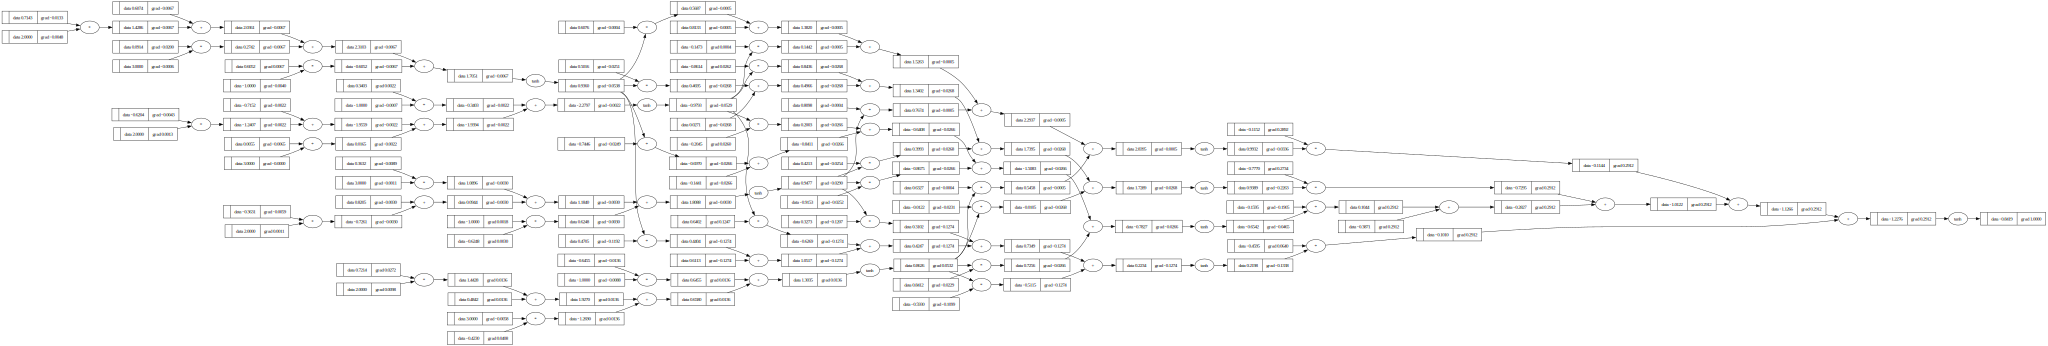

In [19]:
draw_dot(out)

In [20]:
import matplotlib.pyplot as plt

def draw_mlp_from_model(model):
    # 从你的 MLP 对象里自动读结构
    input_size = len(model.layers[0].neurons[0].w)
    layer_sizes = [input_size] + [len(layer.neurons) for layer in model.layers]

    print("网络结构:", " -> ".join(map(str, layer_sizes)))

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.axis("off")

    x_gap = 2.5
    y_gap = 1.0
    radius = 0.18
    positions = {}

    for layer_idx, size in enumerate(layer_sizes):
        x = layer_idx * x_gap
        y_start = (size - 1) * y_gap / 2

        for node_idx in range(size):
            y = y_start - node_idx * y_gap
            positions[(layer_idx, node_idx)] = (x, y)

            circle = plt.Circle(
                (x, y),
                radius,
                facecolor="white",
                edgecolor="black",
                linewidth=1.5,
                zorder=3,
            )
            ax.add_patch(circle)

        ax.text(
            x,
            y_start + 0.65,
            str(size),
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold",
        )

    for layer_idx in range(len(layer_sizes) - 1):
        for i in range(layer_sizes[layer_idx]):
            for j in range(layer_sizes[layer_idx + 1]):
                x1, y1 = positions[(layer_idx, i)]
                x2, y2 = positions[(layer_idx + 1, j)]
                ax.plot([x1, x2], [y1, y2], color="gray", linewidth=0.7, zorder=1)

    ax.set_aspect("equal")
    plt.show()


网络结构: 3 -> 4 -> 4 -> 1


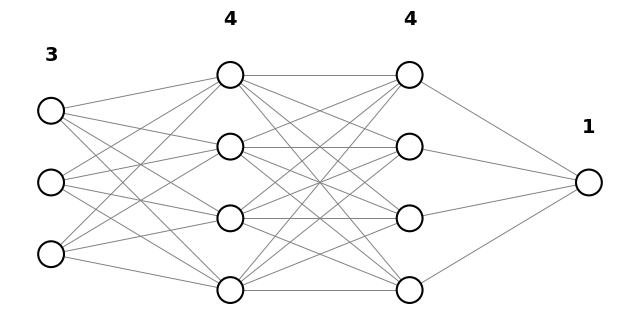

In [21]:
n = MLP(3, [4, 4, 1])
draw_mlp_from_model(n)


In [32]:
xs=[
  [2.0,3.0,-1.0],
  [3.0,-1.0,0.5],
  [0.5,1.0,1.0],
  [1.0,1.0,-1.0],
]
ys=[1.0,-1.0,-1.0,1.0] #desired targets


In [ ]:
for k in range(20):
  #foroward pass
  ypred=[n(x) for x in xs]
  loss=sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))

  #backward pass
  for p in n.parameters():
    p.grad=0.0
  loss.backward()

  #update
  for p in n.parameters():
    p.data+=-0.01*p.grad
  
  print(k,loss.data)
  

0 7.976816324516884
1 7.974849060801568
2 7.972488545226866
3 7.969605075641471
4 7.9660066840316635
5 7.961398126949544
6 7.9553039603428175
7 7.946914541486245
8 7.934752469528755
9 7.915876646525815
10 7.883738989555613
11 7.821460241958558
12 7.676256103852012
13 7.238293350666704
14 5.622036432603114
15 3.5717746378259543
16 0.8377346030180044
17 0.7252075426276656
18 0.220700788597274
19 0.045381465675031415
